Score: 116.3133670816805

In [13]:
# from contextlib import contextmanager
# import time

# @contextmanager
# def timer(name):
#     t0 = time.time()
#     yield
#     print(f"[{name}] done in {(time.time() - t0) * 1000:.1f} msec")

In [14]:
from collections import deque
import bisect
from pathlib import Path
import numpy as np
import z3
from itertools import product
from dataclasses import dataclass, field
import time

In [15]:
def calc_mu_sigma(k, e, vs):
    mu = (k-vs)*e + vs*(1-e)
    sigma = k*e*(1-e)
    return mu, sigma

def is_out_of_range(y, x, N):
    return not ((0 <= x < N) and (0 <= y < N))

# Env

In [16]:
# --------------------  #
class Env:

    def __init__(self, file_path):
        with open(file_path, mode="r") as f:
            lines = f.readlines()
            N, M, ESP = lines[0].split()
            N, M, ESP = int(N), int(M), float(ESP)
            GRID = []
            lines = lines[1:]
            for _line in lines[:M]:
                _line = _line.split()
                ps = []
                for i in range(int(_line[0])):
                    ps.append((int(_line[2 * i + 1]), int(_line[2 * i + 2])))
                GRID.append(ps)
            lines = lines[2*M:]
            ANS_GRID = []
            for _line in lines[:N]:
                ANS_GRID.append(list(map(int, _line.split())))
        
        self.N = N
        self.M = M
        self.esp = ESP
        self.grids = GRID
        self.ans_grid = ANS_GRID

        self.total_size = sum(len(g) for g in self.grids)
        self._score = 0
        self.score = 10 ** 9

        cnt = 0
        for x in range(N):
            for y in range(N):
                if self.ans_grid[y][x] > 0:
                    cnt += 1
        self.ans_point_size = cnt
    
    def query1(self, coordinate):
        y, x = coordinate
        self._score += 1
        return self.ans_grid[y][x]

    def query2(self, coordinates):
        k = len(coordinates)
        vs = sum(self.ans_grid[y][x] for y, x in coordinates)
        mu, sigma = calc_mu_sigma(k, self.esp, vs)
        rng = np.random.default_rng()
        r = rng.normal(mu, sigma)
        self._score += 1 / np.sqrt(k)
        return max(0, round(r))

    def answer(self, coordinates):
        is_ok = self.total_size == sum(self.ans_grid[y][x] for y, x in coordinates)
        if is_ok:
            self.score = self._score
        else:
            self._score += 1
        return is_ok

# Response

In [17]:
# --------------------  #
class ResponseSimulator:

    def __init__(self, n: int, esp: float):
        self.esp = esp
        self.n = n
    
    def env_setting(self, query_num: int):
        mus = []
        for vs in range(201):
            mu, sigma = calc_mu_sigma(query_num, self.esp, vs)
            mus.append(mu)

        mu_mids = []
        for i in range(len(mus)-1):
            mu_mids.append((mus[i] + mus[i+1]) / 2)

        self.query_num = query_num
        self.mu_mids = mu_mids

    def calc_true_val_from_response(self, resp_val):
        return bisect.bisect_left(self.mu_mids, resp_val)

# DivMap

In [18]:
# --------------------  #

@dataclass
class DivMap:
    query_num: int
    N: int
    n: int
    up: int
    left: int
    bottom:int
    right:int
    searched_num:int = 0
    searched_total:int = 0
    searched_points:set = field(default_factory=set)
    not_searched_points: set = field(default_factory=set)

    def evaluate(self):
        if (self.n-self.searched_num) == 0:
            return -10**9
        return (self.query_num - self.searched_total) / (self.n-self.searched_num)

    def query(self, coordinate, resp):
        self.searched_num += 1
        self.searched_total += resp
        self.searched_points.add(tuple(coordinate))
    
    def get_next_point(self):
        d_min = 10 ** 9
        ret = None
        for p in self.not_searched_points:
            y, x = p
            d = max(abs(0-y), (self.N-1-y)) + max(abs(0-x), (self.N-1-x))
            if d < d_min:
                d_min = d
                ret = p
        self.not_searched_points.remove(ret)
        return ret

In [19]:
# --------------------  #
class DivMapSolver():

    TH_CONTINUE = 0.3

    def __init__(self, env:Env):
        self.env = env
        ind_arrs = self._get_div_arr(env.N)
        div_maps = []

        response_simulator = ResponseSimulator(env.N, env.esp)
        for up, bottom in zip(ind_arrs[:-1], ind_arrs[1:]):
            for left, right in zip(ind_arrs[:-1], ind_arrs[1:]):
                points = set()
                n=(right-left) * (bottom-up)
                for x in range(right-left):
                    for y in range(bottom-up):
                        points.add((up+y, left+x))
                response_simulator.env_setting(n)
                query_num = response_simulator.calc_true_val_from_response(env.query2(points))
                div_map = DivMap(
                    N=env.N,
                    query_num=query_num,
                    n=n,
                    up=up,
                    bottom=bottom,
                    left=left,
                    right=right,
                    not_searched_points=points,
                )
                div_maps.append(div_map)
    
        self.div_maps = div_maps
        self.total_size = 0
        self.ans = []

    def _get_div_arr(self, n):
        d =  (n-1) // 4 + 1
        r = 4 * d - n
        ret = [4] * (d-r)
        ret += [3] * r
        sum_ret = [0]
        for i in range(len(ret)):
            sum_ret.append(sum_ret[i] + ret[i])
        return sum_ret

    def get_next_point(self):
        INF = 10**9
        max_val = -INF
        max_div = None
        for d in range(len(self.div_maps)):
            v = self.div_maps[d].evaluate()
            if v > max_val:
                max_val = v
                max_div = d
        self.max_div = max_div
        return self.div_maps[max_div].get_next_point()

    def judge_continue(self):
        max_v = max(self.div_maps[d].evaluate() for d in range(len(self.div_maps)))
        if max_v <= DivMapSolver.TH_CONTINUE:
            return False
        return True
    
    def query(self, coordinate, resp):
        self.total_size += resp
        if resp > 0:
            self.ans.append(coordinate)
        self.div_maps[self.max_div].query(coordinate, resp)
    
    def is_ok(self):
        return self.env.total_size == self.total_size

# BFSSolver

In [20]:
# --------------------  #
class BFSSolver:
    """
    幅優先探索で貪欲的に確定する
    RESULT: 127.69
    """

    def __init__(self, N, total_oil_num):
        self.N = N
        self.grid_count = [[-1 for _ in range(N)] for _ in range(N)]
        self.grid_response = [[False for _ in range(N)] for _ in range(N)]
        self.grid_distance = [[0 for _ in range(N)] for _ in range(N)]
        for x in range(N):
            for y in range(N):
                self.grid_distance[y][x] = min(x + 1, y + 1, N - x, N - y)

        self.total_count = 0
        self.total_oil_nums = total_oil_num

        self.next_grids = set()

    def is_ok(self):
        return self.total_count == self.total_oil_nums

    def get_plus_grids(self):
        ret = []
        for x in range(self.N):
            for y in range(self.N):
                if self.grid_count[y][x] == -1:
                    continue
                if self.grid_count[y][x] > 0:
                    ret.append((y, x))
        return ret

    def response(self, y, x, val):
        self.grid_count[y][x] = val
        self.grid_response[y][x] = True
        if val > 0:
            self.total_count += val
            for dy, dx in [[0, 1], [1, 0], [0, -1], [-1, 0]]:
                ny, nx = y + dy, x + dx
                if not (0 <= nx < self.N and 0 <= ny < self.N):
                    continue
                if not self.grid_response[ny][nx]:
                    self.next_grids.add((ny, nx))
        self._update_distance(y, x)

    def get_next_search_point(self):
        while self.next_grids:
            y, x = self.next_grids.pop()
            if not self.grid_response[y][x]:
                return y, x

        return self._get_far_point_from_wall()

    def _update_distance(self, y, x):
        searched = [[False for _ in range(self.N)] for _ in range(self.N)]
        self.grid_distance[y][x] = 0
        start = [(y, x)]
        search_q = deque(start)
        while search_q:
            py, px = search_q.popleft()
            searched[py][px] = True
            if searched[py][px]:
                continue
            for dy, dx in [[0, 1], [1, 0], [0, -1], [-1, 0]]:
                ny, nx = py + dy, px + dx
                if not (0 <= nx < self.N and 0 <= ny < self.N):
                    continue
                if self.grid_distance[ny][nx] == 0 or searched[ny][nx]:
                    continue
                search_q.append((ny, nx))
                self.grid_distance[ny][nx] = min(
                    self.grid_distance[ny][nx], self.grid_distance[py][px] + 1
                )

    def _get_far_point_from_wall(self):
        max_val = -(10**9)
        ret = None
        for x in range(self.N):
            for y in range(self.N):
                if self.grid_response[y][x]:
                    continue
                if self.grid_distance[y][x] > max_val:
                    max_val = self.grid_distance[y][x]
                    ret = y, x
        if ret is None:
            raise NotImplementedError("Why?")
        return ret

# SMTSolver

In [21]:
# --------------------  #
class SMTSolver():

    def __init__(self, env:Env):
        placements_grid_set = {}
        for m in range(env.M):
            now_grid_set = [[set() for _ in range(env.N)] for _ in range(env.N)]
            target_grids = env.grids[m]
            for x in range(env.N):
                for y in range(env.N):
                    tmp_grids = []
                    is_ok = True
                    for coordinate in target_grids:
                        ny, nx = coordinate[0] + y, coordinate[1] + x
                        if is_out_of_range(ny, nx, env.N):
                            is_ok = False
                            break
                        tmp_grids.append((ny, nx))
                    if not is_ok:
                        continue
                    for coordinate in tmp_grids:
                        ty, tx = coordinate
                        now_grid_set[ty][tx].add((y, x))
            placements_grid_set[m] = now_grid_set
        
        self.placements_grid_set = placements_grid_set

        var_x = {}
        total_grid = {}

        for m, y, x in product(list(range(env.M)), list(range(env.N)), list(range(env.N))):
            var_x[m, y, x] = z3.Bool(f"var_x{m, y, x}")
        for y, x in product(list(range(env.N)), list(range(env.N))):
            total_grid[y, x] = z3.Int(f"total_grid{y, x}")
        
        self.var_x = var_x
        self.total_grid = total_grid

        self.env = env

    def solve(self, querys):
        z3_solver = z3.Solver()
        env = self.env

        # 配列外参照になる場合はダメ
        for m, y, x in product(list(range(env.M)), list(range(env.N)), list(range(env.N))):
            target_grids = env.grids[m]
            for coordinate in target_grids:
                ny, nx = coordinate[0] + y, coordinate[1] + x
                if is_out_of_range(ny, nx, env.N):
                    z3_solver.add(self.var_x[m,y,x]==False)

        # 配置はどれか1つを選択しなければならない
        for m in range(env.M):
            now_vars = []
            for y, x in product(list(range(env.N)), list(range(env.N))):
                ind = y*env.N + x
                self.var_x[m, y, x] = z3.Bool(f"var_x{m, y, x}")
                now_vars.append(self.var_x[m, y, x])
            z3_solver.add(z3.Sum(now_vars) == 1)

        # 配置した箇所に対応するグリッドが加算される
        for y, x in product(list(range(env.N)), list(range(env.N))):
            bool_vars = []
            for m in range(env.M):
                for ty, tx in self.placements_grid_set[m][y][x]:
                    bool_vars.append(self.var_x[m ,ty, tx])
            z3_solver.add(self.total_grid[y, x] == z3.Sum(bool_vars))
        
        # 制約を満たす
        for query in querys:
            coordinate, resp = query
            y, x = coordinate
            z3_solver.add(self.total_grid[y, x] == resp)
        
        # 解を求める
        z3_solver.set('timeout', 350)
        if not z3_solver.check() == z3.sat:
            return None
        model = z3_solver.model()

        placement_ans = []
        for m, y, x in product(list(range(env.M)), list(range(env.N)), list(range(env.N))):
            if model.eval(self.var_x[m, y, x]):
                placement_ans.append((m, y, x))

        point_ans = set()
        for m, y, x in placement_ans:
            target_grids = env.grids[m]
            for coordinate in target_grids:
                ny, nx = coordinate[0] + y, coordinate[1] + x
                point_ans.add((ny, nx))
        

        return point_ans

# Solve

In [22]:
# --------------------  #
def judge_run_smt(env):
    """
    # 10, 5
    # 11, 5
    # 12, 4
    # 13, 3
    # 14, 2
    # 15, 2
    """
    th = [(10, 5), (11, 5), (12, 4), (13, 3), (14, 2), (15, 2)]
    return any(env.N <= n and env.M <= m for n, m in th)

In [23]:
def solve(env: Env):

    TIME_OUT = 1.7

    div_map_solver = DivMapSolver(env=env)
    bfs_solver = BFSSolver(env.N, total_oil_num=env.total_size)
    smt_solver = SMTSolver(env)

    smt_level = [0.075, 0.125, 0.2, 0.3, 0.55, 1]
    start_time = time.time()
    querys = []
    div_map_querys = deque()

    for i in range(1, 500):
        if env.esp <= 0.02 and div_map_solver.judge_continue():
            # --- DivMap Solver --- #
            if div_map_solver.is_ok():
                env.answer(div_map_solver.ans)
                print("DivMap OK")
                break
            coordinate = div_map_solver.get_next_point()
            resp = env.query1(coordinate)
            div_map_solver.query(coordinate, resp)
            querys.append((coordinate, resp))
            div_map_querys.append((coordinate, resp))
        else:
            # --- BFS Solver --- #
            while div_map_querys:
                coordinate, resp = div_map_querys.pop()
                y, x = coordinate
                bfs_solver.response(y, x, resp)

            y, x = bfs_solver.get_next_search_point()
            resp = env.query1((y, x))
            bfs_solver.response(y, x, resp)
            querys.append(((y, x), resp))
            if bfs_solver.is_ok():
                env.answer(bfs_solver.get_plus_grids())
                print("BFS OK")
                break

        # --- SMT Solver --- #
        if not judge_run_smt(env):
            continue
        if time.time() - start_time > TIME_OUT:
            # 実行時間3秒以内に収めるため
            continue
        if i >= env.N**2 * smt_level[0]:
            smt_solver = SMTSolver(env)
            point_ans = smt_solver.solve(querys)
            if point_ans is None:
                continue
            if env.answer(point_ans):
                print("SMT OK")
                break
            smt_level.pop(0)

# Run

In [24]:
import random

TEST_NUM = 100
scores = []
n_size = []
ans_points = []

def main():
    random.seed(0)
    for test_num in range(TEST_NUM):
        env = Env(file_path = Path(f"../in/{test_num:0>4}.txt"))
        n_size.append(env.N**2)
        ans_points.append(env.ans_point_size)
        solve(env)
        scores.append(env.score)
        print(f"[{test_num+1}/{TEST_NUM}] score:{env.score}")
main()

BFS OK
[1/100] score:82.25


SMT OK
[2/100] score:13.25
SMT OK
[3/100] score:62.73803387171259
BFS OK
[4/100] score:80.25
SMT OK
[5/100] score:35.73803387171259
SMT OK
[6/100] score:62.73803387171259
BFS OK
[7/100] score:113.46410161513775
BFS OK
[8/100] score:153.25
BFS OK
[9/100] score:65.48803387171259
BFS OK
[10/100] score:80.25
BFS OK
[11/100] score:101.48803387171259
SMT OK
[12/100] score:19.642734410091837
BFS OK
[13/100] score:194.0474349484711
BFS OK
[14/100] score:135.46410161513774
BFS OK
[15/100] score:140.0
BFS OK
[16/100] score:156.0474349484711
BFS OK
[17/100] score:207.64273441009183
BFS OK
[18/100] score:152.64273441009183
BFS OK
[19/100] score:130.46410161513774
BFS OK
[20/100] score:226.64273441009183
BFS OK
[21/100] score:140.0
SMT OK
[22/100] score:12.488033871712584
BFS OK
[23/100] score:224.0474349484711
SMT OK
[24/100] score:13.25
SMT OK
[25/100] score:24.738033871712584
BFS OK
[26/100] score:117.46410161513775
BFS OK
[27/100] score:194.64273441009183
BFS OK
[28/100] score:227.0474349484711

# Evaluate

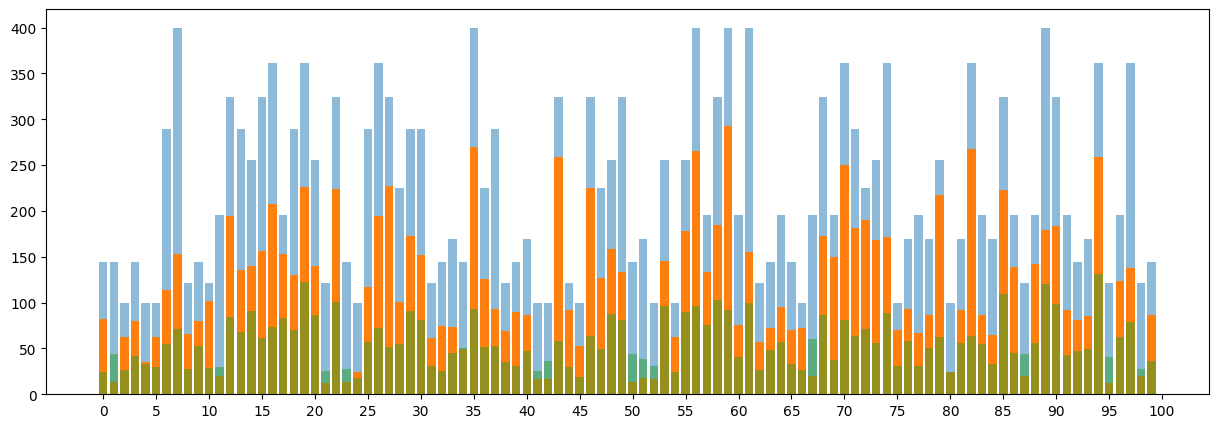

117.2833670816805


In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.bar(list(range(len(n_size))), n_size, alpha=0.5)
plt.bar(list(range(len(scores))), scores)
plt.bar(list(range(len(ans_points))), ans_points, alpha=0.5)

plt.xticks(range(0, len(scores)+1, 5))
plt.show()

print(sum(scores) / len(scores))